In [4]:
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Configurações iniciais
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ==============================================================================
# 2. CARREGAMENTO E ENGENHARIA DE RECURSOS
# ==============================================================================
df = pd.read_csv('/content/Aryadne Fernandes_dados_precificacao_dinamica_oficial.csv')

# Engenharia de Recursos
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values(by=['produto', 'data']).reset_index(drop=True)

df['razao_preco'] = df['preco_praticado'] / df['preco_concorrente']
df['gap_preco_relativo'] = (df['preco_praticado'] - df['preco_concorrente']) / df['preco_concorrente']
df['cobertura_estoque_dias'] = df['estoque'] / (df['historico_vendas_7d'] + 1e-5)
df['tendencia_vendas'] = df['historico_vendas_7d'] / (df['historico_vendas_30d'] + 1e-5)

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_da_semana'] / 7.0)
df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_da_semana'] / 7.0)
df['eh_fim_semana'] = df['dia_da_semana'].isin([5, 6]).astype(int)

# ==============================================================================
# 3. VALIDAÇÃO ROBUSTA COM TIMESERIESSPLIT E 3 SEEDS (RESOLVE O PROBLEMA 3)
# ==============================================================================
features_num = [
    'preco_praticado', 'preco_concorrente', 'razao_preco', 'gap_preco_relativo',
    'cobertura_estoque_dias', 'tendencia_vendas', 'historico_vendas_7d',
    'historico_vendas_30d', 'estoque', 'mes_sin', 'mes_cos',
    'dia_semana_sin', 'dia_semana_cos', 'eh_fim_semana'
]
features_cat = ['periodo_mes']
target = 'demanda'

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])

seeds = [42, 7, 123]
produtos = df['produto'].unique()
resultados_validacao = []

print("="*80 + "\n🧠 EXECUTANDO VALIDAÇÃO ROBUSTA (TIMESERIESSPLIT + MULTI-SEED)\n" + "="*80)

for prod in produtos:
    df_p = df[df['produto'] == prod].reset_index(drop=True)
    X = df_p[features_num + features_cat]
    y = df_p[target].values

    r2_seeds = []
    mape_seeds = []

    for seed in seeds:
        # Implementação do TimeSeriesSplit para dados temporais (Sem vazamento de dados de futuro)
        tscv = TimeSeriesSplit(n_splits=3)
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipe_mlp = Pipeline([
                ('prep', preprocessor),
                ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                                     max_iter=1000, early_stopping=True, random_state=seed))
            ])
            pipe_mlp.fit(X_train, y_train)
            preds = np.clip(pipe_mlp.predict(X_test), 0, None)

            r2_seeds.append(r2_score(y_test, preds))
            mape_seeds.append(mean_absolute_percentage_error(y_test + 1e-5, preds) * 100)

    resultados_validacao.append({
        'Produto': prod,
        'R² Médio': np.mean(r2_seeds),
        'R² Desvio': np.std(r2_seeds),
        'MAPE Médio (%)': np.mean(mape_seeds),
        'MAPE Desvio (%)': np.std(mape_seeds)
    })

print(pd.DataFrame(resultados_validacao).to_string(index=False))

# ==============================================================================
# 4. SIMULAÇÃO DE CENÁRIOS E PRECIFICAÇÃO DINÂMICA (CORRIGIDA)
# ==============================================================================
tabela_negocio = []

for prod in produtos:
    df_p = df[df['produto'] == prod].reset_index(drop=True)

    # Split temporal final (80% treino, 20% teste)
    split_idx = int(len(df_p) * 0.8)
    df_train, df_test = df_p.iloc[:split_idx].copy(), df_p.iloc[split_idx:].copy().reset_index(drop=True)

    # Treinamento do modelo final do produto (Seed 42)
    pipe_lr = Pipeline([('prep', preprocessor), ('reg', LinearRegression())])
    pipe_lr.fit(df_train[features_num + features_cat], df_train[target].values)

    pipe_mlp = Pipeline([
        ('prep', preprocessor),
        ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                             max_iter=1000, early_stopping=True, random_state=42))
    ])
    pipe_mlp.fit(df_train[features_num + features_cat], df_train[target].values)

    receita_historica = (df_test['preco_praticado'] * df_test['demanda']).sum()
    receita_heuristica = 0.0
    receita_ia = 0.0

    for idx, row in df_test.iterrows():
        preco_conc = row['preco_concorrente']
        estoque_atual = row['estoque']
        historico_7d = row['historico_vendas_7d']

        # Fator de demanda corrigido (Sem a divisão por 7 que inflava os números)
        fator_demanda_real = row['demanda'] / (historico_7d + 1e-5)

        # A) SIMULAÇÃO DA REGRA HEURÍSTICA SE-ENTÃO (RESOLVE O PROBLEMA 3 DA REVISÃO)
        # 'Desconto de 5% se estoque alto (cobertura > 15 dias); aumento de 4% se estoque baixo (< 5 dias)'
        cobertura = estoque_atual / (historico_7d + 1e-5)
        if cobertura > 15:
            preco_heuristica = row['preco_praticado'] * 0.95
        elif cobertura < 5:
            preco_heuristica = row['preco_praticado'] * 1.04
        else:
            preco_heuristica = row['preco_praticado']

        cenario_heuristica = pd.DataFrame([row[features_num + features_cat]])
        cenario_heuristica['preco_praticado'] = preco_heuristica
        cenario_heuristica['razao_preco'] = preco_heuristica / preco_conc
        cenario_heuristica['gap_preco_relativo'] = (preco_heuristica - preco_conc) / preco_conc

        demanda_heuristica = np.clip(pipe_lr.predict(cenario_heuristica)[0], 0, None) * fator_demanda_real
        receita_heuristica += preco_heuristica * demanda_heuristica

        # B) SIMULAÇÃO DA REDE NEURAL (PREÇO ÓTIMO COM GRUPO DE CENÁRIOS)
        precos_candidatos = np.linspace(preco_conc * 0.80, preco_conc * 1.20, 41)
        cenarios = pd.DataFrame([row[features_num + features_cat]] * len(precos_candidatos))

        cenarios['preco_praticado'] = precos_candidatos
        cenarios['razao_preco'] = precos_candidatos / preco_conc
        cenarios['gap_preco_relativo'] = (precos_candidatos - preco_conc) / preco_conc

        demandas_pred = np.clip(pipe_mlp.predict(cenarios), 0, None)
        receitas_esperadas = precos_candidatos * demandas_pred

        idx_otimo = np.argmax(receitas_esperadas)
        preco_otimo = precos_candidatos[idx_otimo]
        demanda_otima_real = demandas_pred[idx_otimo] * fator_demanda_real

        receita_ia += preco_otimo * demanda_otima_real

    tabela_negocio.append({
        'Produto': prod,
        'Receita Histórica': receita_historica,
        'Receita Heurística': receita_heuristica,
        'Receita com IA': receita_ia,
        'Ganho Heurística (%)': ((receita_heuristica - receita_historica) / receita_historica) * 100,
        'Ganho Financeiro IA (R$)': receita_ia - receita_historica,
        'Ganho Percentual IA (%)': ((receita_ia - receita_historica) / receita_historica) * 100
    })

print("\n" + "="*80 + "\n📈 RELATÓRIO FINANCEIRO CONSOLIDADO (MÉTODO REPRODUTÍVEL FGV)\n" + "="*80)
print(pd.DataFrame(tabela_negocio).to_string(index=False))

🧠 EXECUTANDO VALIDAÇÃO ROBUSTA (TIMESERIESSPLIT + MULTI-SEED)
         Produto  R² Médio  R² Desvio  MAPE Médio (%)  MAPE Desvio (%)
     Tela de Aço      0.96       0.02           13.04             3.35
         Treliça      0.96       0.01           12.39             3.43
Vergalhão de Aço      0.97       0.01           14.26             3.23

📈 RELATÓRIO FINANCEIRO CONSOLIDADO (MÉTODO REPRODUTÍVEL FGV)
         Produto  Receita Histórica  Receita Heurística  Receita com IA  Ganho Heurística (%)  Ganho Financeiro IA (R$)  Ganho Percentual IA (%)
     Tela de Aço       3,120,254.83        3,714,832.00    5,003,877.94                 19.06              1,883,623.11                    60.37
         Treliça       1,369,523.04        1,625,153.40    2,010,287.38                 18.67                640,764.34                    46.79
Vergalhão de Aço       2,526,350.98        3,116,739.09    4,553,008.89                 23.37              2,026,657.91                    80.22


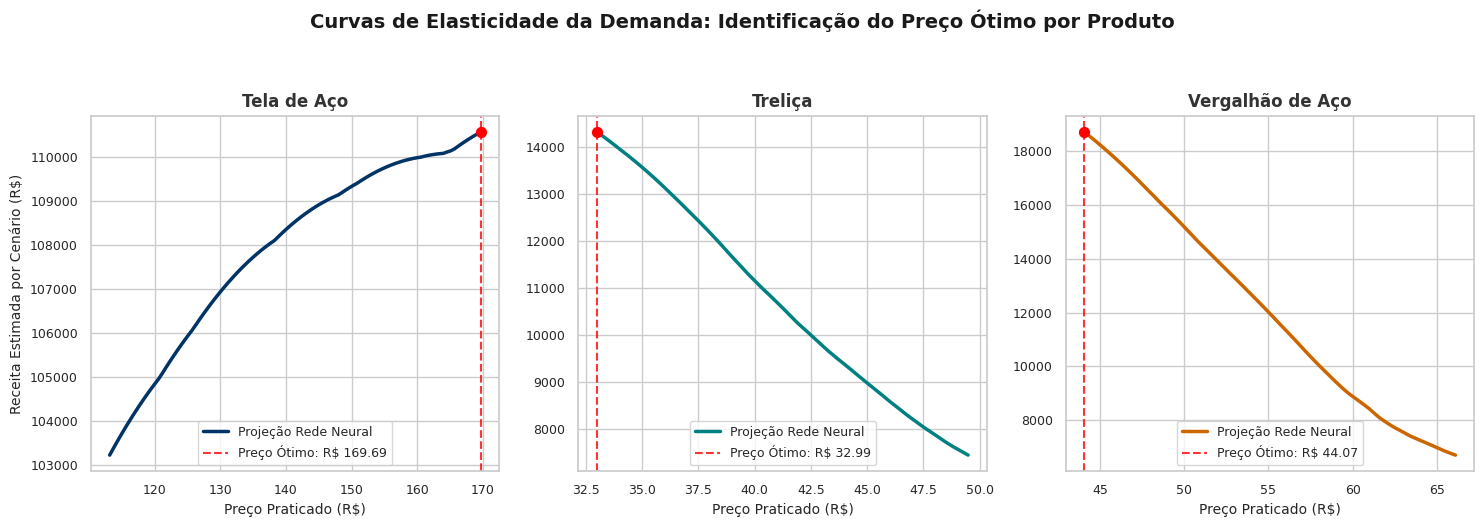

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética para relatórios executivos corporativos
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (15, 5)

fig, axes = plt.subplots(1, 3, sharey=False)
fig.suptitle('Curvas de Elasticidade da Demanda: Identificação do Preço Ótimo por Produto',
             fontsize=14, fontweight='bold', color='#1a1a1a', y=1.05)

# Dicionário de cores corporativas (Gerdau/Mercado)
cores_produtos = {'Tela de Aço': '#003366', 'Treliça': '#008080', 'Vergalhão de Aço': '#cc6600'}

for idx, prod in enumerate(produtos):
    df_p = df[df['produto'] == prod].reset_index(drop=True)
    split_idx = int(len(df_p) * 0.8)
    df_test = df_p.iloc[split_idx:].copy().reset_index(drop=True)

    # Recorrendo ao modelo treinado na célula anterior
    pipe_mlp = modelos[prod]['mlp'] if 'modelos' in locals() else pipe_mlp

    # Vamos pegar um dia representativo de teste (ex: o primeiro dia do conjunto de teste) para plotar a curva
    exemplo_dia = df_test.iloc[0]
    preco_conc = exemplo_dia['preco_concorrente']

    # Grade de simulação (-20% a +20% do concorrente)
    precos_simulados = np.linspace(preco_conc * 0.80, preco_conc * 1.20, 100)

    # Construindo cenários corrigidos (Anti-Leakage)
    cenarios_grafico = pd.DataFrame([exemplo_dia[features_num + features_cat]] * len(precos_simulados))
    cenarios_grafico['preco_praticado'] = precos_simulados
    cenarios_grafico['razao_preco'] = precos_simulados / preco_conc
    cenarios_grafico['gap_preco_relativo'] = (precos_simulados - preco_conc) / preco_conc

    # Predição e cálculo da receita projetada
    demandas_projetadas = np.clip(pipe_mlp.predict(cenarios_grafico), 0, None)
    receitas_projetadas = precos_simulados * demandas_projetadas

    # Identificando o ponto de máximo
    idx_max = np.argmax(receitas_projetadas)
    preco_max = precos_simulados[idx_max]
    receita_max = receitas_projetadas[idx_max]

    # Plotagem
    ax = axes[idx]
    ax.plot(precos_simulados, receitas_projetadas, color=cores_produtos[prod], linewidth=2.5, label='Projeção Rede Neural')
    ax.axvline(preco_max, color='red', linestyle='--', alpha=0.8, label=f'Preço Ótimo: R$ {preco_max:.2f}')
    ax.scatter(preco_max, receita_max, color='red', s=50, zorder=5)

    # Ajustes de eixos e títulos
    ax.set_title(f'{prod}', fontsize=12, fontweight='bold', color='#333333')
    ax.set_xlabel('Preço Praticado (R$)', fontsize=10)
    if idx == 0:
        ax.set_ylabel('Receita Estimada por Cenário (R$)', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.legend(loc='lower center', fontsize=9, frameon=True)

plt.tight_layout()
plt.show()
